170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 375s 473ms/step - accuracy: 0.4048 - loss: 1.7473 - val_accuracy: 0.4331 - val_loss: 1.7207
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 362s 463ms/step - accuracy: 0.5494 - loss: 1.2543 - val_accuracy: 0.5512 - val_loss: 1.2460
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 357s 456ms/step - accuracy: 0.6068 - loss: 1.1034 - val_accuracy: 0.6423 - val_loss: 1.0587
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 357s 456ms/step - accuracy: 0.6450 - loss: 1.0016 - val_accuracy: 0.6222 - val_loss: 1.1491
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 355s 454ms/step - accuracy: 0.6731 - loss: 0.9272 - val_accuracy: 0.6898 - val_loss: 0.9372
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 362s 463ms/step - accuracy: 0.6977 - loss: 0.8744 - val_accuracy: 0.6925 - val_loss: 0.9082
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 374s 453ms/step - accuracy: 0.7097 - loss: 0.8345 - val_accuracy: 0.6779 - val_loss: 0.9184
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 355s 454ms/step - accuracy: 0.7228 -

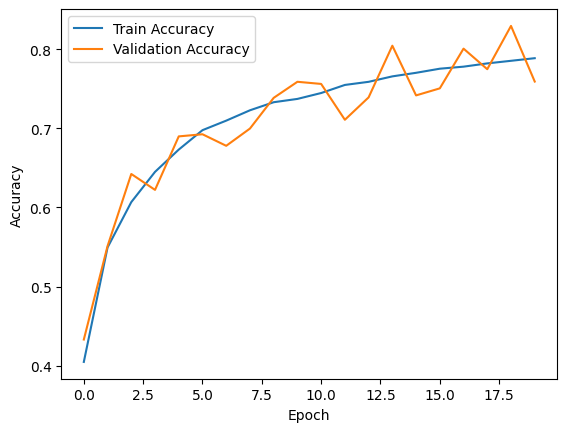

In [ ]:
#lib
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalize images
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(x_train)

# Build CNN model
model = models.Sequential()

# Block 1
model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)))
model.add(layers.BatchNormalization())
model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Dropout(0.25))

# Block 2
model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Dropout(0.25))

# Block 3
model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Dropout(0.25))

# Flatten
model.add(layers.Flatten())

# Fully connected layers
model.add(layers.Dense(256, activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.5))

# Output layer
model.add(layers.Dense(10, activation='softmax'))

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=20,
    validation_data=(x_test, y_test)
)

# Evaluate model
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

# Plot accuracy graph
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()